## 🚗 Car Segmentation using Unsupervised Learning (KMeans Clustering)

Understanding patterns within data is essential for making data-driven decisions, especially when labeled data is not available. Clustering, an unsupervised learning technique, enables us to group similar observations and uncover hidden structures within datasets.

In this project, we perform car segmentation using clustering techniques to identify distinct groups of vehicles based on their characteristics. The dataset consists of various features such as price, mileage, engine specifications, and categorical attributes like make and model.

We begin with Exploratory Data Analysis (EDA) to understand the data distribution, detect patterns, and visualize relationships between features. Using PyCaret, we streamline the clustering workflow, including preprocessing, model building, and evaluation.

🎯 **Goal:**  
To group cars into meaningful clusters based on their similarities, enabling better insights into market segmentation and pricing behavior.

### Importing Required Libraries

In [2]:
import pandas as pd
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.clustering import *

In [7]:
#conda install xlrd

In [16]:
#conda install openpyxl

### Read Data

In [8]:
df=pd.read_excel('cars.xls')

### EDA

In [9]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [10]:
df.tail()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
799,16507.070267,16229,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0
800,16175.957604,19095,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
801,15731.132897,20484,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
802,15118.893228,25979,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
803,13585.636802,35662,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Model     804 non-null    object 
 4   Trim      804 non-null    object 
 5   Type      804 non-null    object 
 6   Cylinder  804 non-null    int64  
 7   Liter     804 non-null    float64
 8   Doors     804 non-null    int64  
 9   Cruise    804 non-null    int64  
 10  Sound     804 non-null    int64  
 11  Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 75.5+ KB


In [12]:
df.shape

(804, 12)

In [13]:
df.describe()

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,21343.143767,19831.934080,5.268657,3.037313,3.527363,0.752488,0.679104,0.723881
std,9884.852801,8196.319707,1.387531,1.105562,0.850169,0.431836,0.467111,0.447355
min,8638.930895,266.000000,4.000000,1.600000,2.000000,0.000000,0.000000,0.000000
25%,14273.073870,14623.500000,4.000000,2.200000,4.000000,1.000000,0.000000,0.000000
50%,18024.995019,20913.500000,6.000000,2.800000,4.000000,1.000000,1.000000,1.000000
75%,26717.316636,25213.000000,6.000000,3.800000,4.000000,1.000000,1.000000,1.000000
max,70755.466717,50387.000000,8.000000,6.000000,4.000000,1.000000,1.000000,1.000000


In [17]:
statistics = df.describe()              # Calculates basic statistics for a DataFrame
statistics.to_excel('statistics.xlsx')  # save as excel

In [18]:
df.columns

Index(['Price', 'Mileage', 'Make', 'Model', 'Trim', 'Type', 'Cylinder',
       'Liter', 'Doors', 'Cruise', 'Sound', 'Leather'],
      dtype='object')

In [19]:
df.isnull().sum()

Price       0
Mileage     0
Make        0
Model       0
Trim        0
Type        0
Cylinder    0
Liter       0
Doors       0
Cruise      0
Sound       0
Leather     0
dtype: int64

In [20]:
df['Model'].unique()

array(['Century', 'Lacrosse', 'Lesabre', 'Park Avenue', 'CST-V', 'CTS',
       'Deville', 'STS-V6', 'STS-V8', 'XLR-V8', 'AVEO', 'Cavalier',
       'Classic', 'Cobalt', 'Corvette', 'Impala', 'Malibu', 'Monte Carlo',
       'Bonneville', 'G6', 'Grand Am', 'Grand Prix', 'GTO', 'Sunfire',
       'Vibe', '9_3', '9_3 HO', '9_5', '9_5 HO', '9-2X AWD', 'Ion',
       'L Series'], dtype=object)

In [21]:
df['Type'].unique()

array(['Sedan', 'Convertible', 'Hatchback', 'Coupe', 'Wagon'],
      dtype=object)

### Data Visualization

In [22]:
df['Make'].value_counts(normalize=True)

Make
Chevrolet    0.398010
Pontiac      0.186567
SAAB         0.141791
Buick        0.099502
Cadillac     0.099502
Saturn       0.074627
Name: proportion, dtype: float64

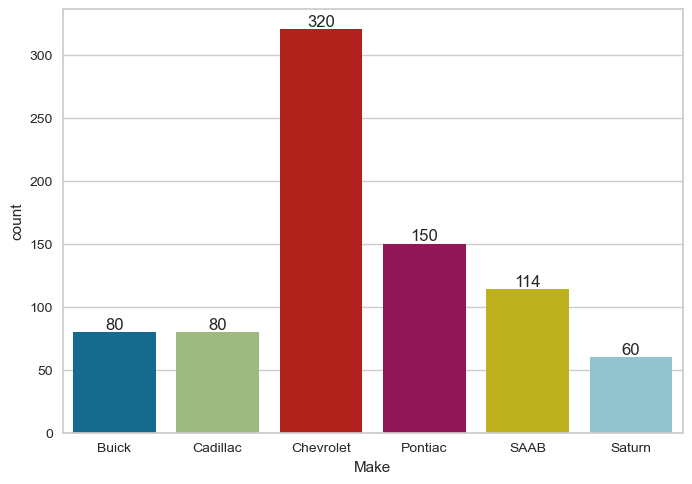

In [23]:
ax=sns.countplot(x=df['Make'],hue=df['Make'])
for container in ax.containers:
    ax.bar_label(container)

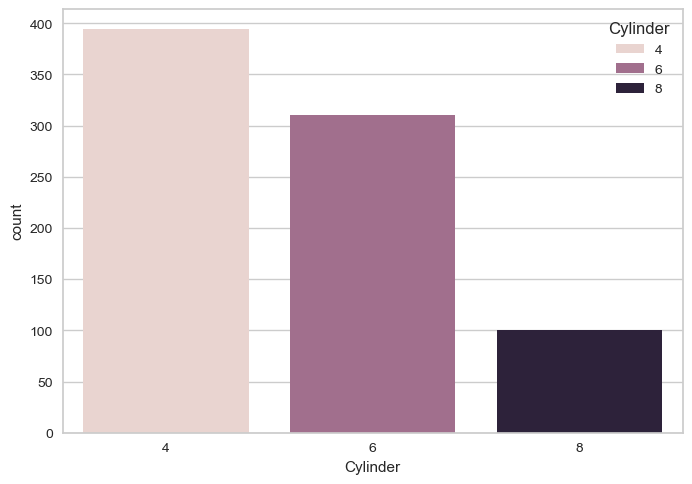

In [24]:
sns.countplot(x=df['Cylinder'],hue=df['Cylinder']);

In [25]:
df['Cylinder'].value_counts()

Cylinder
4    394
6    310
8    100
Name: count, dtype: int64

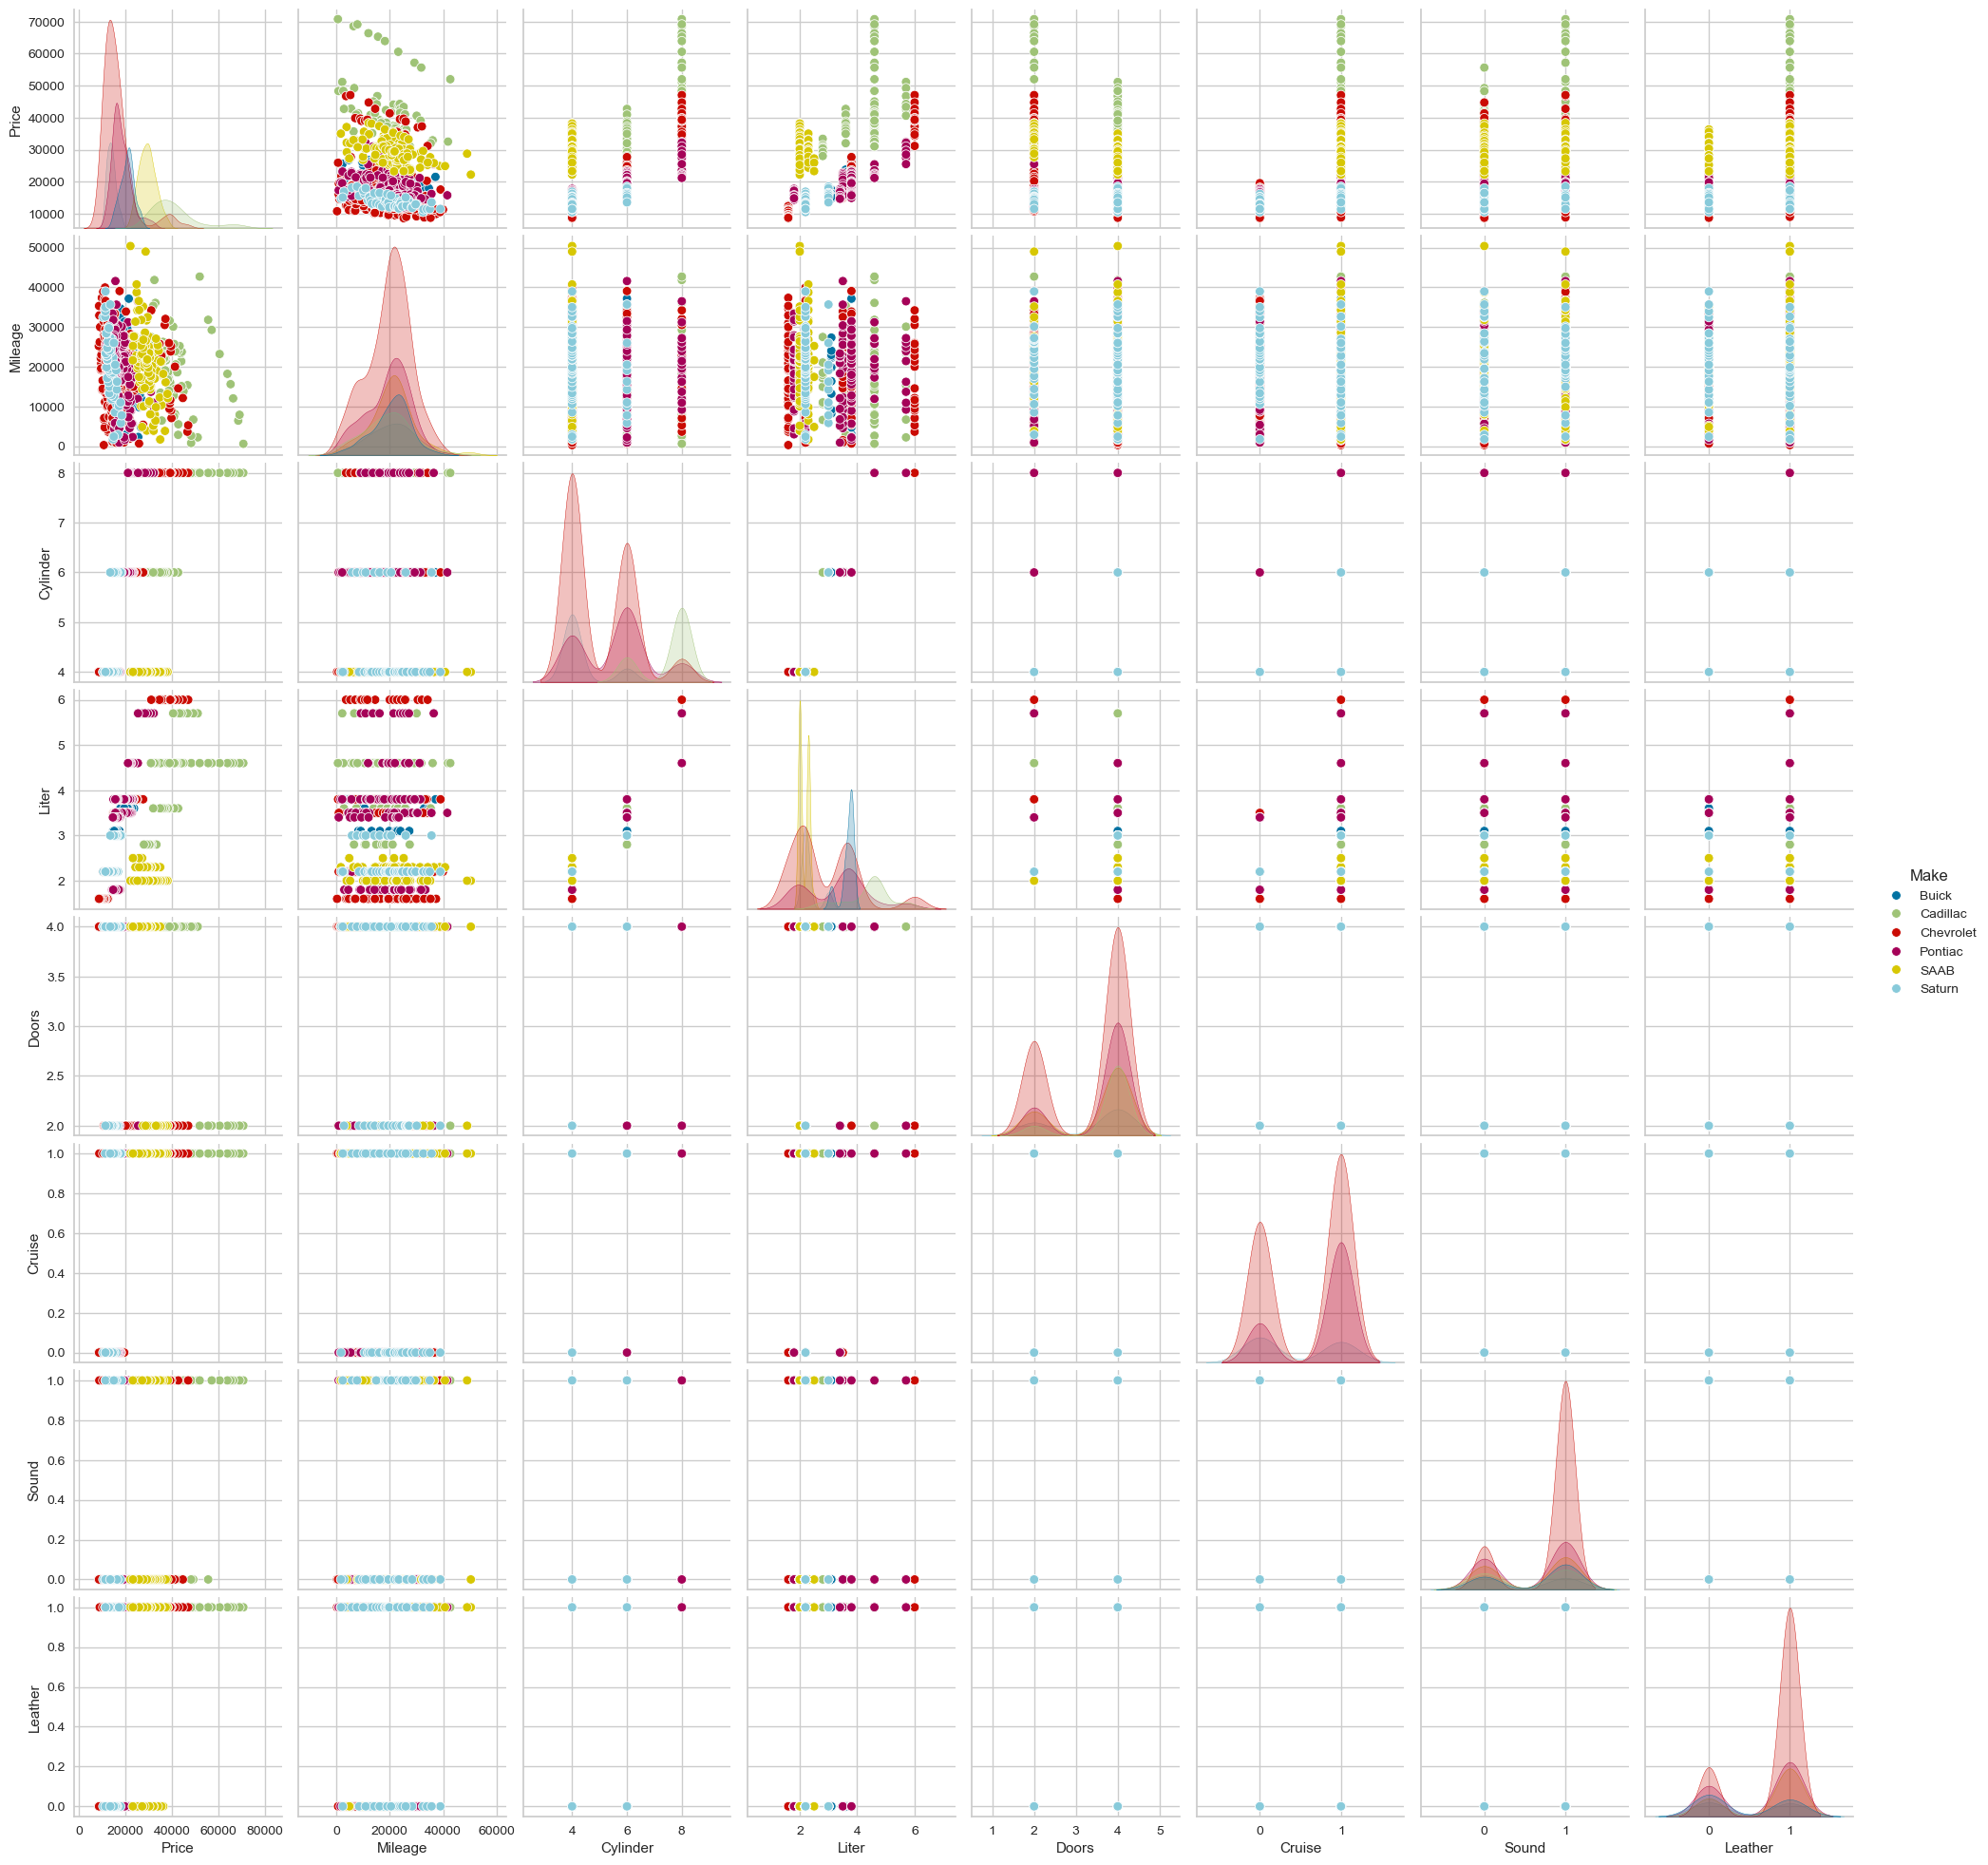

In [27]:
sns.pairplot(df,hue='Make');

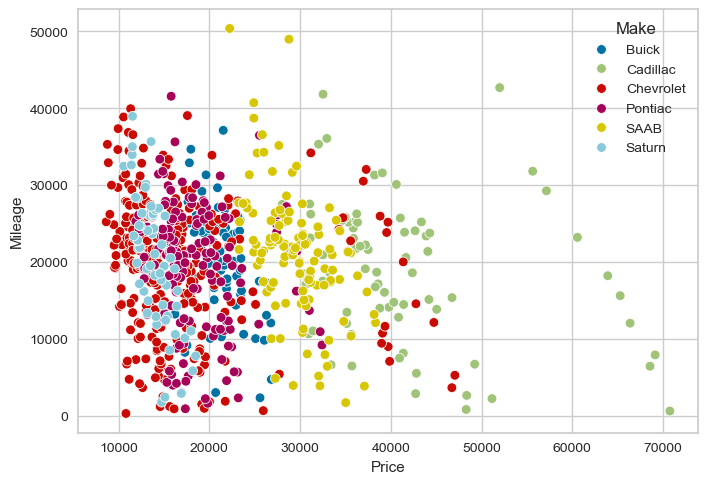

In [28]:
sns.scatterplot(x=df['Price'],y=df['Mileage'],hue=df['Make']);

<Axes: ylabel='count'>

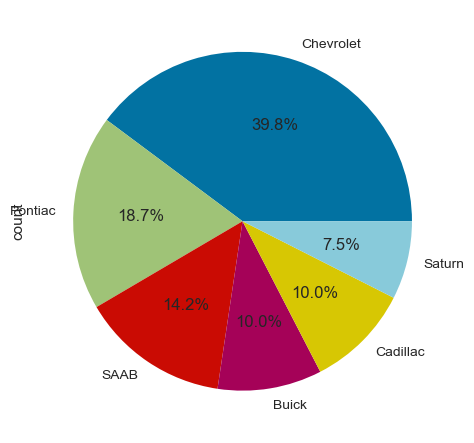

In [29]:
df['Make'].value_counts().plot.pie(autopct='%1.1f%%')

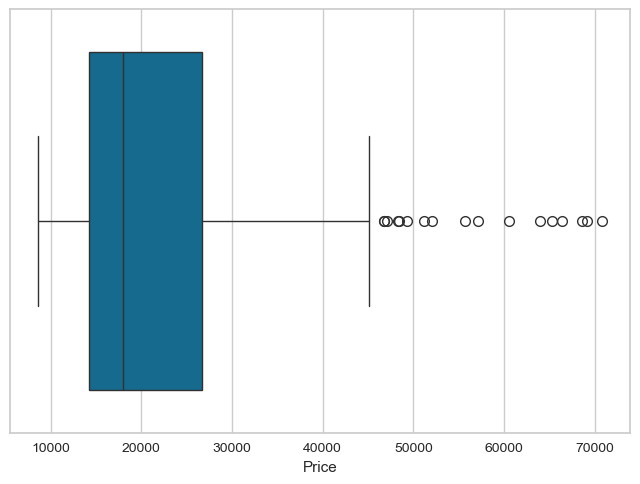

In [30]:
sns.boxplot(x='Price',data=df);

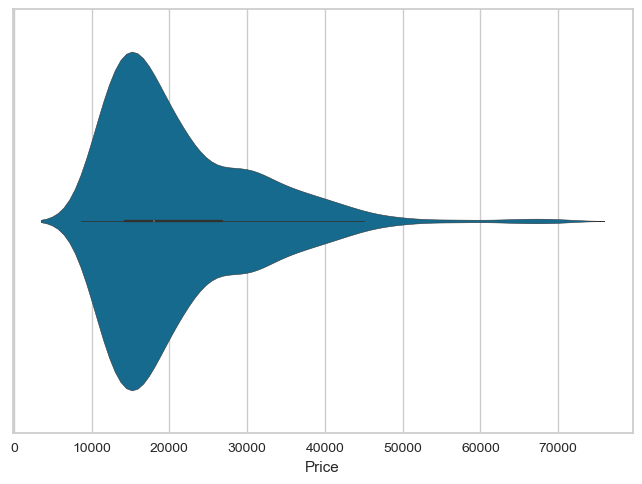

In [31]:
sns.violinplot(x='Price',data=df);

### Modelling

In [32]:
setup(df);

,Description,Value
0,Session id,1646
1,Original data shape,"(804, 12)"
2,Transformed data shape,"(804, 98)"
3,Numeric features,8
4,Categorical features,4
5,Preprocess,True
6,Imputation type,simple
7,Numeric imputation,mean
8,Categorical imputation,mode
9,Maximum one-hot encoding,-1


In [33]:
kmeans=create_model('kmeans',4)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4115,600.9108,0.8838,0,0,0


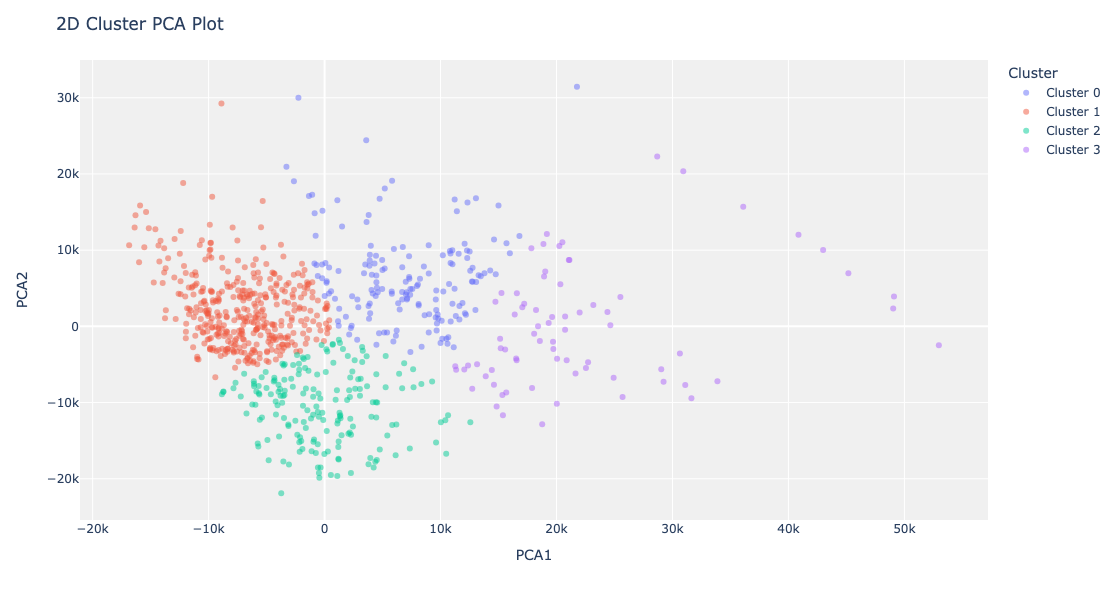

In [34]:
plot_model(kmeans)

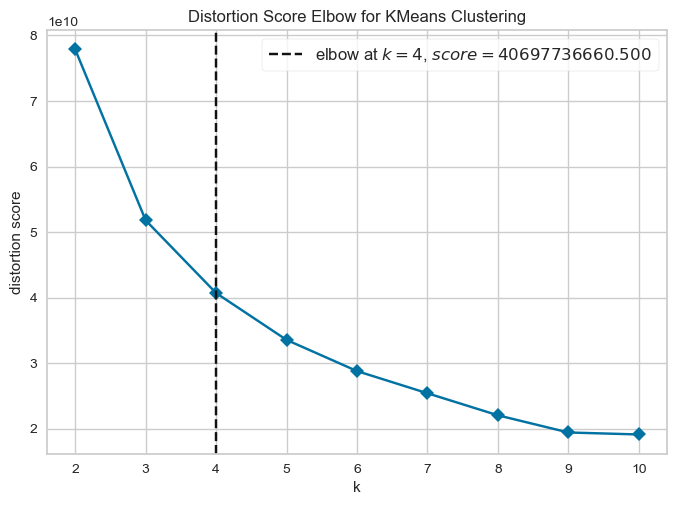

In [35]:
plot_model(kmeans, plot='elbow')

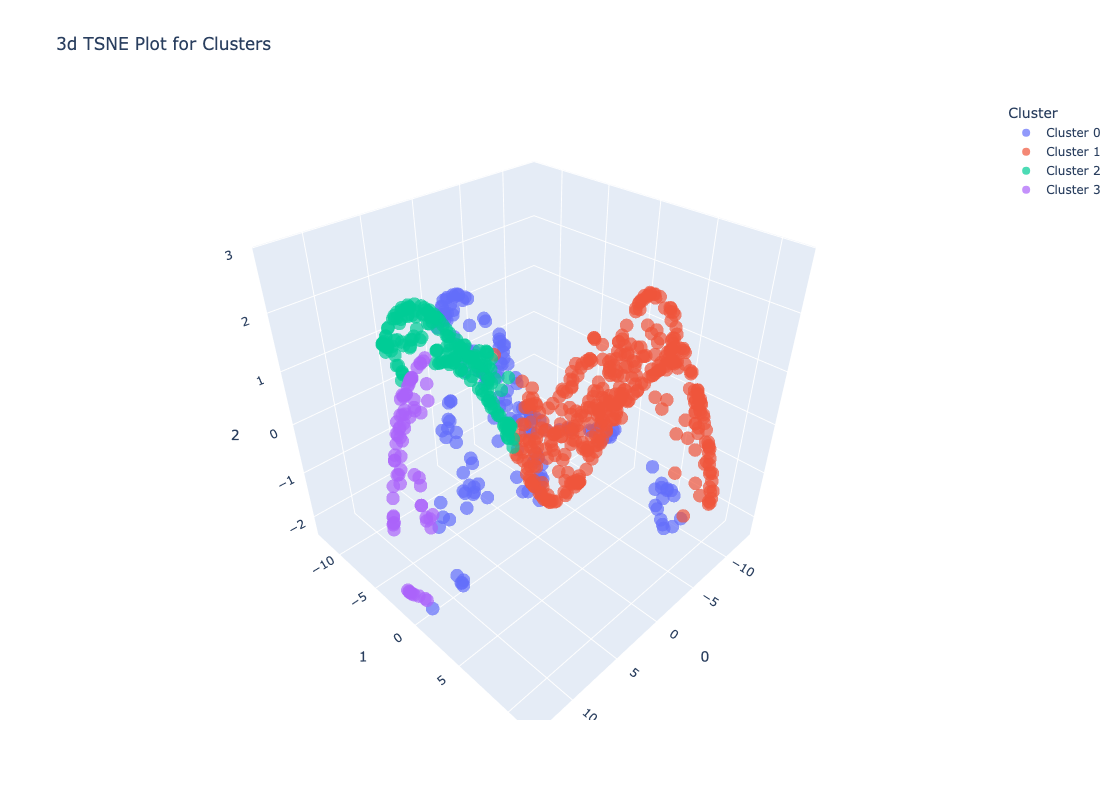

In [36]:
plot_model(kmeans, plot='tsne')

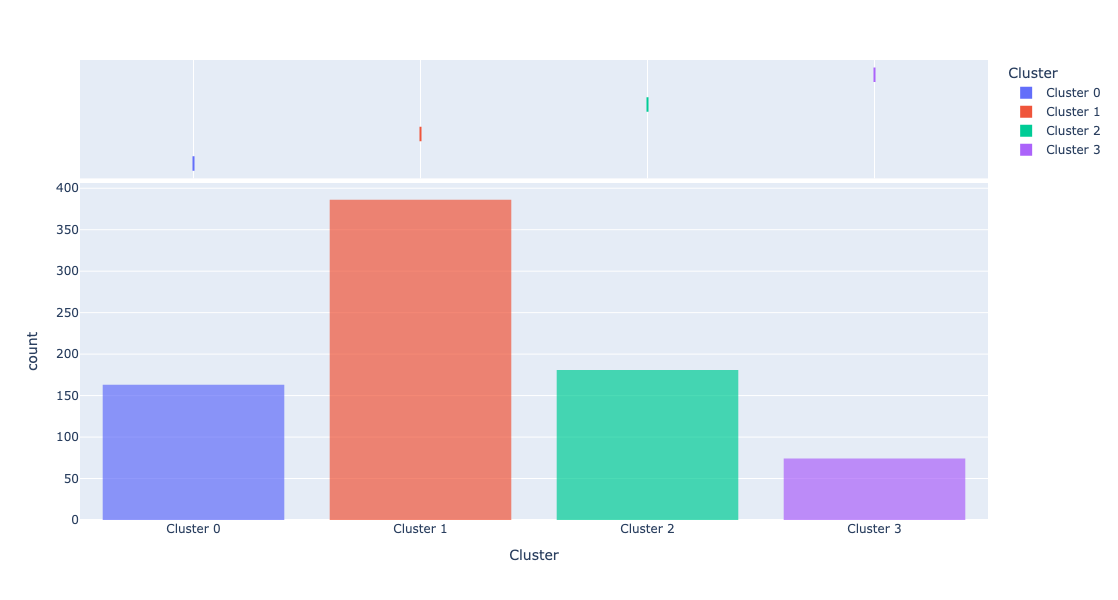

In [37]:
plot_model(kmeans, plot='distribution')

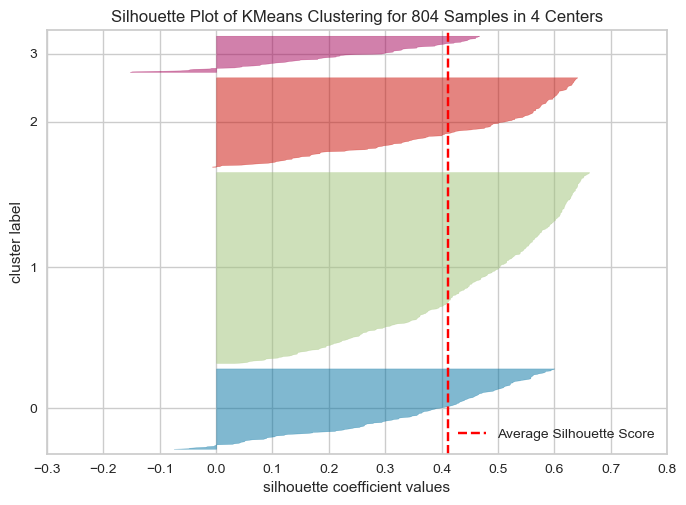

In [38]:
plot_model(kmeans, plot='silhouette')

## Conclusion

In this project, we applied unsupervised learning techniques to segment cars into distinct groups using KMeans clustering. Through Exploratory Data Analysis, we identified key patterns and relationships between features such as price, mileage, and engine characteristics.

The clustering results reveal meaningful groupings of vehicles, which can be interpreted as different market segments. Visualization techniques such as t-SNE and silhouette plots provided insights into cluster separation and quality.

Key takeaways:
- Clustering effectively groups cars with similar characteristics without labeled data  
- Price and mileage play a significant role in defining clusters  
- Visualization techniques help validate cluster quality and interpretability  

💡 **Insights:**
- Distinct segments likely represent economy, mid-range, and luxury vehicles  
- Feature relationships are non-linear, making clustering a powerful approach  
  
Overall, this project demonstrates how unsupervised learning can uncover hidden structures in data and provide valuable insights for decision-making in real-world applications.